# Consumer Shopping Trends Analysis

In this notebook we will be studying a certain dataset containing data about consumer preferences. We will perform an EDA to see what the actual trends are, and if people are leaning more toward e-commerce in this technological world. 

Then, different ML models will be built to predict whether a certain consumer will buy online, at the store or even both of them.

In [1]:
# Necessary imports for EDA.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [2]:
# Importing data
consumer_data = pd.read_csv("../data/Consumer_Shopping_Trends_2026.csv")

In [3]:
# print(consumer_data.head())
print(consumer_data.info())
print("Null values accros entire dataset: ", consumer_data.isnull().sum().sum())

<class 'pandas.DataFrame'>
RangeIndex: 11789 entries, 0 to 11788
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          11789 non-null  int64  
 1   monthly_income               11789 non-null  int64  
 2   daily_internet_hours         11789 non-null  float64
 3   smartphone_usage_years       11789 non-null  int64  
 4   social_media_hours           11789 non-null  float64
 5   online_payment_trust_score   11789 non-null  int64  
 6   tech_savvy_score             11789 non-null  int64  
 7   monthly_online_orders        11789 non-null  int64  
 8   monthly_store_visits         11789 non-null  int64  
 9   avg_online_spend             11789 non-null  int64  
 10  avg_store_spend              11789 non-null  int64  
 11  discount_sensitivity         11789 non-null  int64  
 12  return_frequency             11789 non-null  int64  
 13  avg_delivery_days          

As there are no null values, we would like to check for misspelling accros the text columns.

In [4]:
string_columns = ["gender", "city_tier", "shopping_preference"]
for column in string_columns:
    print(consumer_data[column].unique())

<StringArray>
['Other', 'Male', 'Female']
Length: 3, dtype: str
<StringArray>
['Tier 3', 'Tier 1', 'Tier 2']
Length: 3, dtype: str
<StringArray>
['Store', 'Hybrid', 'Online']
Length: 3, dtype: str


There are indeed no misspelling in this columns. It is also important to notice that these values will be encoded later for our ML models, as there are clear distinctions between each option in each column.

Next, we will like to see which of the variables influence the most our target one, shopping preference. For that, we will first encode our string columns to later perform a correlation heatmap so we can assess this influence. Notice we do encode our target variable using LabelEncoder and not a one hot encoder technique.

In [5]:
# Encoding
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
encoded_consumer = pd.get_dummies(consumer_data, columns=["city_tier", "gender"],
                                  dtype="int32")
encoded_consumer["shopping_preference"] = encoder.fit_transform(encoded_consumer["shopping_preference"])
encoder.classes_

array(['Hybrid', 'Online', 'Store'], dtype=object)

In [6]:
# Saving encoder params
joblib.dump(encoder, 'label_encoder.pkl')

['label_encoder.pkl']

In [7]:
encoded_consumer.head()

,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,...,brand_loyalty_score,environmental_awareness,time_pressure_level,shopping_preference,city_tier_Tier 1,city_tier_Tier 2,city_tier_Tier 3,gender_Female,gender_Male,gender_Other
0,56,221111,6.5,12,0.7,1,6,16,16,28551,...,6,5,2,2,0,0,1,0,0,1
1,69,96029,8.2,13,2.7,6,9,14,1,124056,...,8,1,7,0,0,0,1,0,1,0
2,46,19055,6.4,4,2.1,10,8,2,0,81939,...,3,3,3,2,0,0,1,1,0,0
3,32,53170,6.4,11,0.7,2,10,20,3,35901,...,2,6,6,2,1,0,0,1,0,0
4,60,244016,6.0,5,0.7,2,5,18,16,131971,...,7,1,6,2,0,0,1,0,1,0


As we can see in the following chart, it is very clear that the average spend on store by the customers gives a strong indicator of what their shopping preferences are: the higher you spend on stores the more likely "Store" is your shopping preference.

C:\Users\Juan\AppData\Local\Temp\ipykernel_22368\3080325526.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Hybrid", "Online", "Store"])


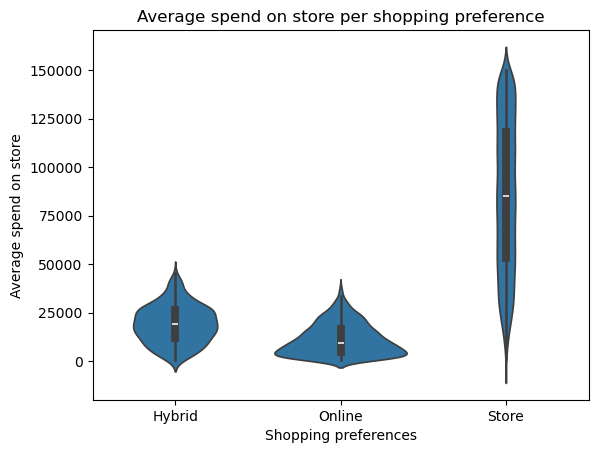

In [8]:
fig, ax = plt.subplots()
sns.violinplot(x="shopping_preference", y="avg_store_spend", data=encoded_consumer)
ax.set_xticklabels(["Hybrid", "Online", "Store"])
ax.set_xlabel("Shopping preferences")
ax.set_ylabel("Average spend on store")
ax.set_title("Average spend on store per shopping preference")
plt.show()

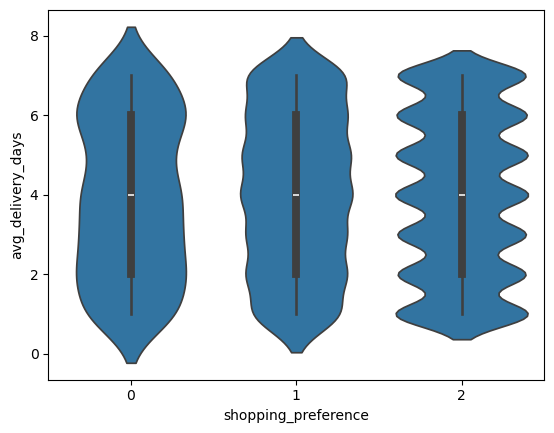

In [9]:
sns.violinplot(x="shopping_preference", y="avg_delivery_days", data=encoded_consumer)
plt.show()

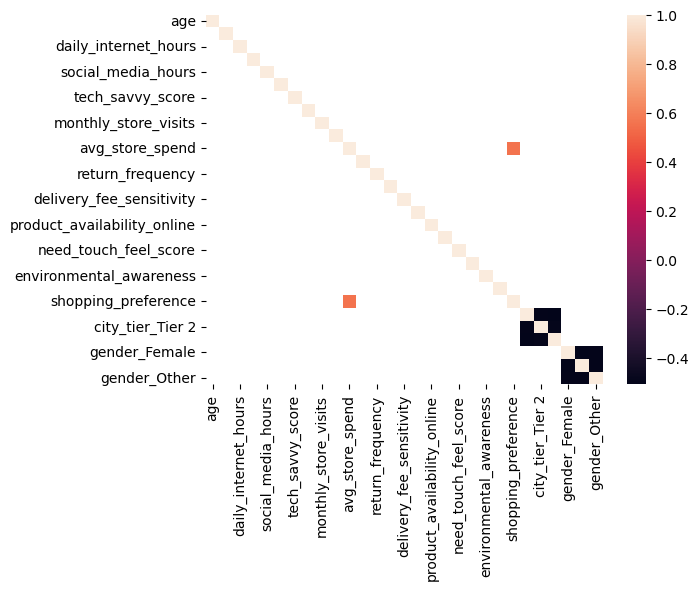

In [10]:
# Correlation Heatmap

sns.heatmap(encoded_consumer.corr(method="spearman")[abs(encoded_consumer.corr(method="spearman"))>0.4], 
            annot=False)
plt.show()

<Axes: xlabel='shopping_preference', ylabel='count'>

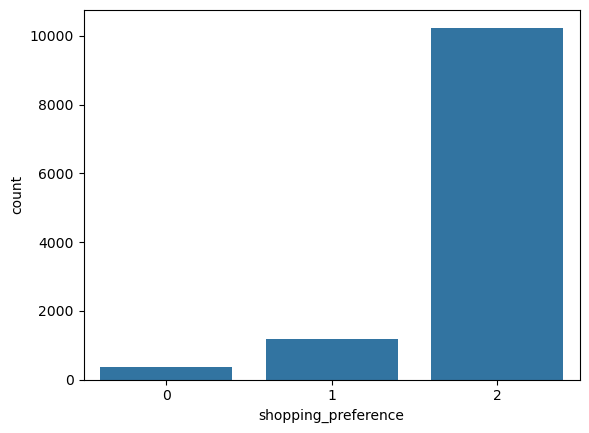

In [11]:
sns.countplot(x="shopping_preference", data=encoded_consumer)

## Model predictions

Let us try a quick XGBModel to test our feature importance to further analyze the dataset.

In [12]:
from xgboost import XGBClassifier, plot_importance
from sklearn.model_selection import train_test_split
from sklearn.metrics import multilabel_confusion_matrix, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import class_weight

In [13]:
X = encoded_consumer.drop("shopping_preference", axis=1)
y = encoded_consumer["shopping_preference"]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=73)
xgb_model = XGBClassifier(random_state = 73)
xgb_model.fit(X_train, y_train)
predictions = xgb_model.predict(X_test)
score = confusion_matrix(y_test, predictions)
print(score)
ConfusionMatrixDisplay(confusion_matrix=score)
plt.show()

[[  14   25   35]
 [   9  219    7]
 [   6    2 2041]]


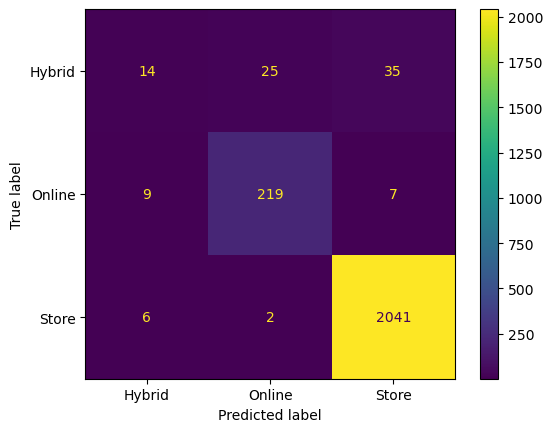

In [15]:
ConfusionMatrixDisplay.from_predictions(y_test, predictions, 
                                        display_labels=["Hybrid", "Online", "Store"])
plt.show()

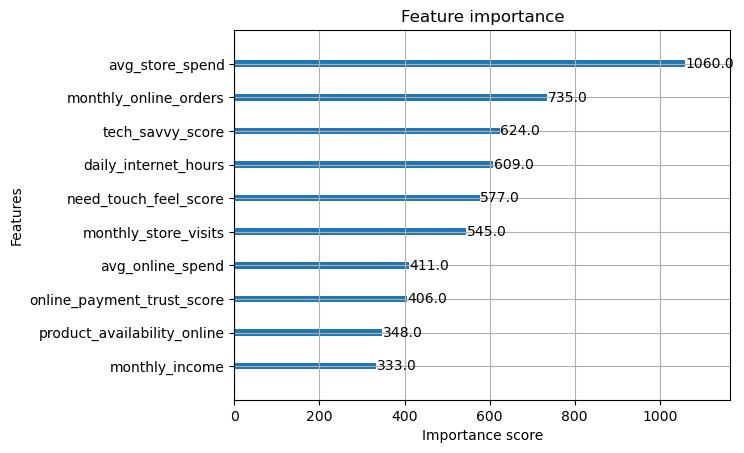

In [16]:
plot_importance(xgb_model, max_num_features=10)
plt.show()

As we can see in both the confusion matrix and the features importance graph, our prior variable "avg_store_spend" is really determining and helping our model to correctly predict this shopping preference, while it is struggling with the hybrid preference. This could be to lack of clear relations regarding this preference, or the fact that it is the least numerous class of the three, so the model has fewer data to learn, meanwhile Store is the highest count preference in our dataset.

In [17]:
from sklearn.model_selection import RandomizedSearchCV

In [18]:
# Hyperparameter tuning for xgboost model
param_distributions = {
    "n_estimators": [100, 300, 500],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.05, 0.1],
    "min_child_weight": [1, 5],
    "max_delta_step": [1, 5],
    "subsample": [0.8],
    "colsample_bytree": [0.8]
}

xgb_hypermodel = RandomizedSearchCV(XGBClassifier(), param_distributions=param_distributions,
                                    n_jobs=-1, cv=5, verbose = 3, n_iter=15,
                                    scoring="f1_macro", random_state = 73)
xgb_hypermodel.fit(X_train, y_train)

Fitting 5 folds for each of 15 candidates, totalling 75 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.8], 'learning_rate': [0.05, 0.1], 'max_delta_step': [1, 5], 'max_depth': [3, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchan

In [19]:
xgb_hypermodel.best_params_

{'subsample': 0.8,
 'n_estimators': 500,
 'min_child_weight': 5,
 'max_depth': 3,
 'max_delta_step': 5,
 'learning_rate': 0.1,
 'colsample_bytree': 0.8}

In [20]:
predictions_hypermodel = xgb_hypermodel.predict(X_test)
score_hypermodel = confusion_matrix(y_test, predictions_hypermodel)
print(score_hypermodel)
ConfusionMatrixDisplay(confusion_matrix=score_hypermodel)
plt.show()

[[  20   21   33]
 [   5  229    1]
 [   9    0 2040]]


It is very clear that we have improved accuracy and precision on both shopping preference: Online and Store, but the Hybrid one is only a bit better, but still so far off what we would like. We will need more samples on this class to further improved the predictions.

### Saving configurations for main.py file

In [21]:
joblib.dump(xgb_hypermodel.best_estimator_, "final_xgb_model.pkl")

['final_xgb_model.pkl']